# RNN Baseline

В этом ноутбуке последовательностный baseline расширяется до сравнения двух рекуррентных архитектур: `GRU` и `LSTM`. Цель этапа — понять, насколько обе модели превосходят простые последовательностные baseline'ы и даёт ли `LSTM` содержательный выигрыш по сравнению с `GRU` в задаче `next-event prediction`.


## План
1. Загрузить подготовленные данные и зафиксированный split.
2. Посчитать простые sequence baseline-модели: `MostPopular` и `Markov1`.
3. Обучить две рекуррентные модели в одинаковой постановке: `GRU` и `LSTM`.
4. Сравнить их по `MRR`, `Hit@5` и `Hit@10` на `val/test`.
5. Сохранить эмбеддинги и чекпоинты обеих моделей для дальнейшего downstream-сравнения.


In [ ]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import polars as pl
import torch
from torch.utils.data import DataLoader

from src.baselines import Markov1Baseline, MostPopularBaseline, evaluate_baseline
from src.data import EventWindowDataset, build_next_event_examples, load_prepared_sequences
from src.eval import evaluate_next_event_model
from src.export import build_user_embeddings
from src.models import GRUEncoder, LSTMEncoder
from src.splits import apply_user_split, load_user_split
from src.train import choose_device, seed_everything, train_model

plt.style.use('seaborn-v0_8-whitegrid')
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)

polars.config.Config

In [ ]:
DATA_DIR = PROJECT_ROOT / 'artifacts' / 'data'
RNN_DIR = PROJECT_ROOT / 'artifacts' / 'rnn'
RNN_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MAX_LEN = 128
STRIDE = 64
EVENT_DIM = 64
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.0
BATCH_SIZE = 128
EPOCHS = 5
LR = 1e-3
KS = (5, 10)
MODEL_ORDER = ['GRU', 'LSTM']
MODEL_COLORS = {
    'MostPopular': '#94a3b8',
    'Markov1': '#64748b',
    'GRU': '#0f766e',
    'LSTM': '#2563eb',
}

print(f'DATA_DIR={DATA_DIR}')
print(f'RNN_DIR={RNN_DIR}')
print(f'SEED={SEED}, MAX_LEN={MAX_LEN}, STRIDE={STRIDE}, EVENT_DIM={EVENT_DIM}, HIDDEN_DIM={HIDDEN_DIM}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, LR={LR}')

DATA_DIR=/Users/fedornikonov/hse_recsys_rnn/artifacts/data
RNN_DIR=/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn
SEED=42, MAX_LEN=128, STRIDE=64, EVENT_DIM=64, HIDDEN_DIM=128, BATCH_SIZE=128, EPOCHS=5, LR=0.001


## 1. Загрузка подготовленных данных

Используются последовательности и split, полученные на предыдущем этапе preprocessing. Это гарантирует, что оценка `RNN` проводится на том же наборе пользователей, который будет использоваться далее и для других моделей.


In [3]:
prepared = load_prepared_sequences(DATA_DIR)
split = load_user_split(DATA_DIR / 'split.json')
split_prepared = apply_user_split(prepared, split)

train_prepared = split_prepared['train']
val_prepared = split_prepared['val']
test_prepared = split_prepared['test']

print(f'total_users={len(prepared.user_ids)}')
print(f'train_users={len(train_prepared.user_ids)}')
print(f'val_users={len(val_prepared.user_ids)}')
print(f'test_users={len(test_prepared.user_ids)}')
print(f'vocab_size={len(prepared.event2idx)}')

total_users=52495
train_users=36746
val_users=7874
test_users=7875
vocab_size=81


Вывод.

Данные и split загрузились корректно: в распоряжении модели находится **52,495** пользователей и словарь из **81** события. Размеры `train`, `val` и `test` совпадают с предыдущим этапом preprocessing, поэтому дальнейшее сравнение baseline-моделей проводится на том же фиксированном наборе пользователей.


## 2. Протокол оценки

Во всех экспериментах ниже используется одна и та же постановка задачи: по префиксу последовательности предсказать следующее событие. Основные метрики — `Hit@5`, `Hit@10` и `MRR`.


In [4]:
val_examples = build_next_event_examples(val_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)
test_examples = build_next_event_examples(test_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)

protocol_df = pl.DataFrame(
    {
        'split': ['val', 'test'],
        'num_users': [len(val_prepared.user_ids), len(test_prepared.user_ids)],
        'num_examples': [len(val_examples), len(test_examples)],
        'max_len': [MAX_LEN, MAX_LEN],
        'stride': [STRIDE, STRIDE],
    }
)
protocol_df

split,num_users,num_examples,max_len,stride
str,i64,i64,i64,i64
"""val""",7874,130845,128,64
"""test""",7875,124950,128,64


Вывод.

На `val` и `test` сформировано соответственно **130,845** и **124,950** примеров для задачи `next-event prediction`. Это достаточно крупный объём offline-оценки, поэтому различия между baseline-моделями и `GRU` можно интерпретировать как содержательные, а не как эффект маленькой выборки.


## 3. Простые baseline-модели

Перед обучением `GRU` оцениваются две простые модели: глобальная популярность событий и `Markov1`-переходы между соседними событиями. Это позволяет понять, насколько нетривиальна задача `next-event prediction` на текущем датасете.


In [5]:
most_popular = MostPopularBaseline(vocab_size=len(prepared.event2idx)).fit(train_prepared.user_sequences)
markov1 = Markov1Baseline(vocab_size=len(prepared.event2idx)).fit(train_prepared.user_sequences)

baseline_rows = []
for split_name, examples in [('val', val_examples), ('test', test_examples)]:
    for model_name, baseline in [('MostPopular', most_popular), ('Markov1', markov1)]:
        metrics = evaluate_baseline(baseline, examples, ks=KS)
        baseline_rows.append(
            {
                'model': model_name,
                'split': split_name,
                'mrr': metrics['mrr'],
                'hit@5': metrics['hit@5'],
                'hit@10': metrics['hit@10'],
            }
        )

baseline_metrics_df = pl.DataFrame(baseline_rows)
baseline_metrics_df

model,split,mrr,hit@5,hit@10
str,str,f64,f64,f64
"""MostPopular""","""val""",0.458765,0.721052,0.887531
"""Markov1""","""val""",0.81595,0.9408,0.977638
"""MostPopular""","""test""",0.459388,0.727811,0.890996
"""Markov1""","""test""",0.812799,0.93952,0.976543


Вывод.

Простые baseline-модели задают сильную нижнюю границу качества. `MostPopular` даёт умеренный результат, тогда как `Markov1` уже очень силён: на `test` его `MRR` достигает **0.8128**, а `Hit@10` — **0.9765**. Это означает, что задача во многом локально предсказуема, и `GRU` должна обгонять не слабый, а уже весьма конкурентный baseline.


## 4. Подготовка `GRU` и `LSTM` для обучения
Обе архитектуры обучаются в одной и той же sequence-постановке и при одинаковых гиперпараметрах. Это делает сравнение чистым: различия в качестве можно будет объяснять именно выбором рекуррентной ячейки, а не разницей в preprocessing или режиме обучения.


In [6]:
seed_everything(SEED)
device = choose_device()

train_dataset = EventWindowDataset(train_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)
val_dataset = EventWindowDataset(val_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)
test_dataset = EventWindowDataset(test_prepared.user_sequences, max_len=MAX_LEN, stride=STRIDE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model_builders = {
    'GRU': GRUEncoder,
    'LSTM': LSTMEncoder,
}

setup_df = pl.DataFrame(
    {
        'parameter': ['device', 'train_windows', 'val_windows', 'test_windows', 'vocab_size', 'event_dim', 'hidden_dim', 'models'],
        'value': pl.Series(
            'value',
            [str(device), len(train_dataset), len(val_dataset), len(test_dataset), len(prepared.event2idx), EVENT_DIM, HIDDEN_DIM, ', '.join(MODEL_ORDER)],
            strict=False,
        ),
    }
)
setup_df

parameter,value
str,str
"""device""","""mps"""
"""train_windows""","""592094"""
"""val_windows""","""130845"""
"""test_windows""","""124950"""
"""vocab_size""","""81"""
"""event_dim""","""64"""
"""hidden_dim""","""128"""
"""models""","""GRU, LSTM"""


Вывод.
Подготовка данных одинакова для обеих рекуррентных моделей: одна и та же нарезка окон, одинаковые loaders и одинаковые гиперпараметры. Значит, дальнейшее различие в метриках можно будет интерпретировать именно как эффект выбора архитектуры, а не как следствие разных условий обучения.


## 5. Обучение `GRU` и `LSTM`
Обучение проводится последовательно для двух архитектур. Сначала сохраняются train loss-кривые, затем по этим же моделям будут посчитаны одинаковые `val/test`-метрики и извлечены пользовательские эмбеддинги.


In [7]:
trained_models = {}
training_histories = {}

for model_name in MODEL_ORDER:
    seed_everything(SEED)
    model = model_builders[model_name](
        vocab_size=len(prepared.event2idx),
        event_dim=EVENT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(device)
    print(f'=== Training {model_name} ===')
    history = train_model(
        model,
        train_loader,
        device=device,
        epochs=EPOCHS,
        lr=LR,
    )
    trained_models[model_name] = model
    training_histories[model_name] = history

=== Training GRU ===
epoch=01 loss=0.7408
epoch=02 loss=0.6772
epoch=03 loss=0.6692
epoch=04 loss=0.6647
epoch=05 loss=0.6616
=== Training LSTM ===
epoch=01 loss=0.7560
epoch=02 loss=0.6803
epoch=03 loss=0.6697
epoch=04 loss=0.6640
epoch=05 loss=0.6603


In [8]:
history_rows = []
for model_name in MODEL_ORDER:
    for epoch, loss_value in enumerate(training_histories[model_name], start=1):
        history_rows.append({'model': model_name, 'epoch': epoch, 'train_loss': loss_value})
history_df = pl.DataFrame(history_rows)
history_df

model,epoch,train_loss
str,i64,f64
"""GRU""",1,0.740842
"""GRU""",2,0.67721
"""GRU""",3,0.669151
"""GRU""",4,0.664684
"""GRU""",5,0.66164
"""LSTM""",1,0.756001
"""LSTM""",2,0.680314
"""LSTM""",3,0.669705
"""LSTM""",4,0.663984


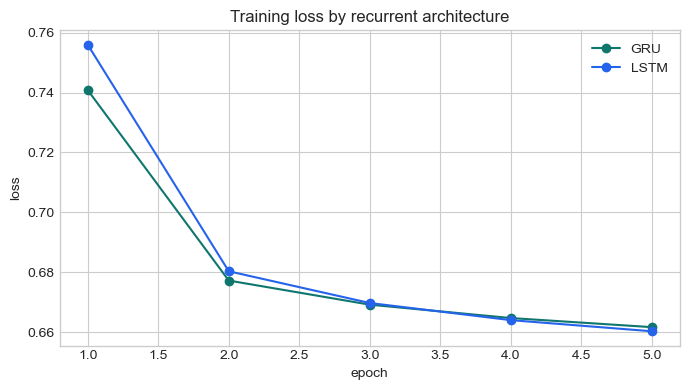

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for model_name in MODEL_ORDER:
    subset = history_df.filter(pl.col('model') == model_name)
    ax.plot(
        subset['epoch'].to_list(),
        subset['train_loss'].to_list(),
        marker='o',
        label=model_name,
        color=MODEL_COLORS[model_name],
    )
ax.set_title('Training loss by recurrent architecture')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend()
plt.tight_layout()
plt.show()

Вывод.
Обе модели обучаются стабильно и выходят на очень близкие значения train loss. К пятой эпохе `GRU` достигает **0.6616**, а `LSTM` — **0.6603**, то есть `LSTM` оптимизируется чуть лучше, но без качественного отрыва. Уже на этом этапе видно, что если преимущество `LSTM` и существует, то оно, скорее всего, будет небольшим.


## 6. Метрики `GRU` и `LSTM` на `val` и `test`
На этом шаге обе рекуррентные модели сравниваются с `MostPopular` и `Markov1` в одной таблице. Это завершает sequence-часть и даёт контекст для дальнейшей downstream-оценки их эмбеддингов.


In [ ]:
rnn_metric_rows = []
for model_name in MODEL_ORDER:
    model = trained_models[model_name]
    val_metrics = evaluate_next_event_model(model, val_loader, device=device, ks=KS)
    test_metrics = evaluate_next_event_model(model, test_loader, device=device, ks=KS)
    rnn_metric_rows.extend(
        [
            {
                'model': model_name,
                'split': 'val',
                'loss': val_metrics['loss'],
                'mrr': val_metrics['mrr'],
                'hit@5': val_metrics['hit@5'],
                'hit@10': val_metrics['hit@10'],
            },
            {
                'model': model_name,
                'split': 'test',
                'loss': test_metrics['loss'],
                'mrr': test_metrics['mrr'],
                'hit@5': test_metrics['hit@5'],
                'hit@10': test_metrics['hit@10'],
            },
        ]
    )

rnn_metrics_df = pl.DataFrame(rnn_metric_rows).sort(['split', 'model'])
rnn_metrics_df

model,split,loss,mrr,hit@5,hit@10
str,str,f64,f64,f64,f64
"""GRU""","""test""",0.657299,0.880358,0.968614,0.990983
"""LSTM""","""test""",0.655829,0.880583,0.968862,0.991083
"""GRU""","""val""",0.649591,0.881784,0.969084,0.991166
"""LSTM""","""val""",0.648332,0.881904,0.969277,0.991267


In [ ]:
comparison_df = pl.concat(
    [
        baseline_metrics_df.with_columns(pl.lit(None).cast(pl.Float64).alias('loss')).select(['model', 'split', 'loss', 'mrr', 'hit@5', 'hit@10']),
        rnn_metrics_df.select(['model', 'split', 'loss', 'mrr', 'hit@5', 'hit@10']),
    ],
    how='vertical_relaxed',
).sort(['split', 'model'])
comparison_df

model,split,loss,mrr,hit@5,hit@10
str,str,f64,f64,f64,f64
"""GRU""","""test""",0.657299,0.880358,0.968614,0.990983
"""LSTM""","""test""",0.655829,0.880583,0.968862,0.991083
"""Markov1""","""test""",null,0.812799,0.93952,0.976543
"""MostPopular""","""test""",null,0.459388,0.727811,0.890996
"""GRU""","""val""",0.649591,0.881784,0.969084,0.991166
"""LSTM""","""val""",0.648332,0.881904,0.969277,0.991267
"""Markov1""","""val""",null,0.81595,0.9408,0.977638
"""MostPopular""","""val""",null,0.458765,0.721052,0.887531


Вывод.
Обе рекуррентные модели уверенно превосходят `MostPopular` и сильный `Markov1` baseline. При этом `LSTM` оказывается лишь незначительно лучше `GRU`: на `test` её `MRR` составляет **0.8806** против **0.8804** у `GRU`, а `Hit@10` — **0.9911** против **0.9910**. Значит, на sequence-задаче `LSTM` даёт лишь минимальный дополнительный выигрыш.


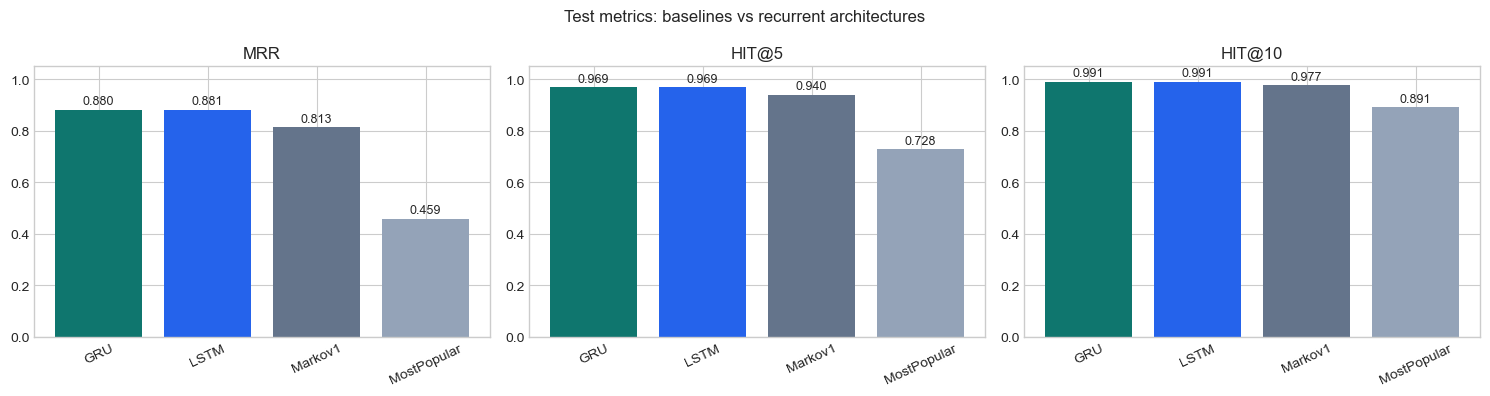

In [12]:
test_comparison_df = comparison_df.filter(pl.col('split') == 'test').sort('model')
metrics_to_plot = ['mrr', 'hit@5', 'hit@10']
models = test_comparison_df['model'].to_list()
colors = [MODEL_COLORS[model_name] for model_name in models]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, metrics_to_plot):
    values = test_comparison_df[metric].to_list()
    ax.bar(models, values, color=colors)
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=25)
    for idx, value in enumerate(values):
        ax.text(idx, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Test metrics: baselines vs recurrent architectures')
plt.tight_layout()
plt.show()


In [13]:
test_metrics_lookup = {row['model']: row for row in test_comparison_df.to_dicts()}
gains_df = pl.DataFrame(
    {
        'metric': ['mrr', 'hit@5', 'hit@10'],
        'GRU - Markov1': [
            test_metrics_lookup['GRU']['mrr'] - test_metrics_lookup['Markov1']['mrr'],
            test_metrics_lookup['GRU']['hit@5'] - test_metrics_lookup['Markov1']['hit@5'],
            test_metrics_lookup['GRU']['hit@10'] - test_metrics_lookup['Markov1']['hit@10'],
        ],
        'LSTM - Markov1': [
            test_metrics_lookup['LSTM']['mrr'] - test_metrics_lookup['Markov1']['mrr'],
            test_metrics_lookup['LSTM']['hit@5'] - test_metrics_lookup['Markov1']['hit@5'],
            test_metrics_lookup['LSTM']['hit@10'] - test_metrics_lookup['Markov1']['hit@10'],
        ],
        'LSTM - GRU': [
            test_metrics_lookup['LSTM']['mrr'] - test_metrics_lookup['GRU']['mrr'],
            test_metrics_lookup['LSTM']['hit@5'] - test_metrics_lookup['GRU']['hit@5'],
            test_metrics_lookup['LSTM']['hit@10'] - test_metrics_lookup['GRU']['hit@10'],
        ],
    }
)
gains_df


metric,GRU - Markov1,LSTM - Markov1,LSTM - GRU
str,f64,f64,f64
"""mrr""",0.067559,0.067784,0.000225
"""hit@5""",0.029095,0.029342,0.000248
"""hit@10""",0.014441,0.01454,0.000099


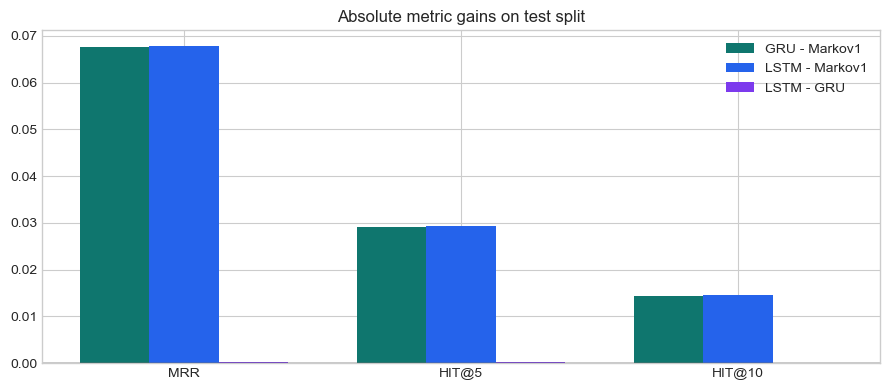

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
metrics = gains_df['metric'].to_list()
x = range(len(metrics))
width = 0.25
series = [
    ('GRU - Markov1', '#0f766e', -width),
    ('LSTM - Markov1', '#2563eb', 0.0),
    ('LSTM - GRU', '#7c3aed', width),
]
for column_name, color, shift in series:
    values = gains_df[column_name].to_list()
    ax.bar([i + shift for i in x], values, width=width, label=column_name, color=color)
ax.axhline(0.0, color='black', linewidth=1)
ax.set_xticks(list(x))
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_title('Absolute metric gains on test split')
ax.legend()
plt.tight_layout()
plt.show()


Вывод.
Графики подтверждают, что обе рекуррентные модели выигрывают у эвристических baseline'ов, но разница между `GRU` и `LSTM` остаётся очень небольшой. Это важный промежуточный вывод: если в downstream-задаче `LSTM` не покажет преимуществ, это будет означать, что ключевой эффект уже исчерпан на уровне `GRU`, а не скрыт в недооценённой sequence-метрике.


## 7. Построение и сохранение пользовательских эмбеддингов
После sequence-сравнения из обеих рекуррентных моделей извлекаются пользовательские эмбеддинги. `GRU`-артефакты сохраняются по прежним путям для совместимости с уже собранным downstream-пайплайном, а для `LSTM` добавляются отдельные файлы.


In [15]:
embedding_tables = {}
for model_name in MODEL_ORDER:
    embedding_tables[model_name] = build_user_embeddings(
        trained_models[model_name],
        prepared,
        max_len=MAX_LEN,
        batch_size=BATCH_SIZE,
        device=device,
    )
    print(model_name, embedding_tables[model_name].shape)

embedding_tables['GRU'].head(5)


GRU (52495, 129)
LSTM (52495, 129)


appmetrica_device_id,emb_000,emb_001,emb_002,emb_003,emb_004,emb_005,emb_006,emb_007,emb_008,…,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10000279983408954705""",-0.878042,-0.976265,-0.418455,0.847853,-0.999981,0.767859,-0.687452,-0.151041,0.887971,…,0.681669,0.614472,0.037311,-0.288075,-0.095589,0.449348,-0.930731,-0.140843,0.754401,0.364304
"""10000413951987079100""",-0.458689,-0.952395,-0.542166,0.288809,-0.997966,-0.154703,0.137829,-0.637919,0.996763,…,0.542415,-0.811837,0.365994,-0.58591,-0.906328,0.990161,-0.946528,0.330231,-0.92799,-0.513599
"""10000644478552013109""",0.894376,0.396944,-0.626659,-0.202101,-0.574368,0.979351,-0.099898,-0.701689,-0.405823,…,-0.832109,-0.886396,-0.653947,0.744418,-0.857651,-0.85843,0.979631,0.619027,0.913021,-0.810827
"""10000833103973120938""",-0.023612,0.808958,-0.1936,0.143008,-0.23047,0.926211,-0.918596,-0.98655,-0.219441,…,0.474626,-0.788757,-0.526732,0.643894,-0.931546,-0.215252,-0.801793,0.714173,0.814326,-0.864137
"""1000084260249595813""",0.341443,0.466537,0.536662,0.344723,-0.980395,-0.338711,-0.893655,0.746908,0.802707,…,0.138854,-0.780093,-0.791776,-0.780447,-0.874776,0.808795,-0.934463,0.564568,-0.987757,-0.899716


In [16]:
history_path = RNN_DIR / 'training_history.csv'
comparison_path = RNN_DIR / 'comparison_metrics.csv'

gru_embeddings_path = RNN_DIR / 'user_embeddings.parquet'
lstm_embeddings_path = RNN_DIR / 'user_embeddings_lstm.parquet'

gru_model_path = RNN_DIR / 'rnn_encoder.pt'
lstm_model_path = RNN_DIR / 'lstm_encoder.pt'

gru_config_path = RNN_DIR / 'rnn_config.json'
lstm_config_path = RNN_DIR / 'lstm_config.json'

history_df.write_csv(history_path)
comparison_df.write_csv(comparison_path)
embedding_tables['GRU'].write_parquet(gru_embeddings_path)
embedding_tables['LSTM'].write_parquet(lstm_embeddings_path)

common_config = {
    'max_len': MAX_LEN,
    'stride': STRIDE,
    'event_dim': EVENT_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'lr': LR,
    'seed': SEED,
}

for model_name, model_path, config_path in [
    ('GRU', gru_model_path, gru_config_path),
    ('LSTM', lstm_model_path, lstm_config_path),
]:
    torch.save(
        {
            'model_state_dict': trained_models[model_name].state_dict(),
            'config': common_config | {'model_type': model_name.lower()},
            'event2idx': prepared.event2idx,
        },
        model_path,
    )
    config_path.write_text(
        json.dumps(common_config | {'model_type': model_name.lower()}, ensure_ascii=False, indent=2),
        encoding='utf-8',
    )

saved_rnn_paths = {
    'history': history_path,
    'comparison': comparison_path,
    'gru_embeddings': gru_embeddings_path,
    'lstm_embeddings': lstm_embeddings_path,
    'gru_model': gru_model_path,
    'lstm_model': lstm_model_path,
    'gru_config': gru_config_path,
    'lstm_config': lstm_config_path,
}
saved_rnn_paths


{'history': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn/training_history.csv'),
 'comparison': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn/comparison_metrics.csv'),
 'gru_embeddings': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn/user_embeddings.parquet'),
 'lstm_embeddings': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn/user_embeddings_lstm.parquet'),
 'gru_model': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn/rnn_encoder.pt'),
 'lstm_model': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn/lstm_encoder.pt'),
 'gru_config': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn/rnn_config.json'),
 'lstm_config': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/rnn/lstm_config.json')}

## Итог

На этом этапе sequence-baseline расширен до прямого сравнения `GRU` и `LSTM` в задаче `next-event prediction`. Обе модели заметно превосходят `MostPopular` и `Markov1`, однако `LSTM` даёт только очень небольшой прирост относительно `GRU`.

Одновременно сохранены пользовательские эмбеддинги и чекпоинты обеих моделей. Это позволяет перейти к downstream-сравнению уже с пониманием, что на самой sequence-задаче `LSTM` не меняет картину радикально, а значит её практическая ценность должна проверяться уже через прикладные метрики retention.
